# Notebook Regresion Lineal 1 Reto: Interlub
Author: A. Ramirez-Morales (andres.ramirez@tec.mx)


## Instrucciones:
- Complete las funciones donde vea líneas de código inconclusas
- Use comentarios para documentar de manera integral sus funciones
- Pruebe sus funciones con distintos parámetros
- Aumente las explicaciones en el Markdown y en el código
- Procure NO usar chatGPT ú otra tecnología similar, usted tiene la capacidad intelectual suficiente para resolverlo por usted mismo
- Use la documentación oficial de las librerías que se utilizan
- Se entrega un archivo PDF CANVAS como lo indique el profesor
- Active el kernel proveniente de `Anaconda`
- Complete las funciones donde vea líneas de código inconclusas
- Use comentarios para documentar de manera integral sus funciones
- Pruebe sus funciones con distintos parámetros
- Aumente las explicaciones en el Markdown y en el código
- Prohibido usar chatGPT ú otra tecnología similar, usted tiene la capacidad intelectual suficiente para resolverlo por usted mismo
- Use la documentación oficial de las librerías que se utilizan
- Se entrega un archivo PDF CANVAS como lo indique el profesor



In [3]:
# cargar librerías básicas
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, shapiro
import pandas as pd

# 0. Datos disponibles

 Cargar los datos como pandas data frame

In [4]:
df = pd.read_csv('datos_grasas_Tec_limpio.csv')

Dele un vistazo a los datos (tambien abralos en excel)

In [5]:
def glimpse(df):
    """
    completar documentacion
    """
    print("Data Types:")
    print(df.dtypes)
    print("\nShape:", df.shape)
    print("\nFirst few rows:")
    print(df.head())


# llame a la funcion


In [6]:
glimpse(df)

Data Types:
idDatosGrasas                                 int64
codigoGrasa                                  object
Aceite Base                                  object
Espesante                                    object
Grado NLGI Consistencia                     float64
Viscosidad del Aceite Base a 40°C. cSt      float64
Penetración de Cono a 25°C, 0.1mm            object
Punto de Gota, °C                            object
Estabilidad Mecánica, %                      object
Punto de Soldadura Cuatro Bolas, kgf        float64
Desgaste Cuatro Bolas, mm                   float64
Indice de Carga-Desgaste                    float64
Carga Timken Ok, lb                          object
Resistencia al Lavado por Agua a 80°C, %     object
Corrosión al Cobre                           object
Registro NSF                                float64
Factor de Velocidad                         float64
Temperatura de Servicio °C, min               int64
Temperatura de Servicio °C, max               int64


## 1. Procesamiento de datos

### 1.1. Quitar columnas que no necesitamos
*Ejercicio:* Analice que columnas va a quitar, anote una justificación clara de por que esta quitando estas columnas

In [7]:
df_reduced = df.drop(columns=['codigoGrasa','subtitulo','descripcion', 'beneficios', 'aplicaciones', 'categoria', 'idDatosGrasas', 'Corrosión al Cobre', 'Indice de Carga-Desgaste'], axis=1)

#### Justificar el por que nos desahacemos de una columna
- Motivo por que eliminar "codigoGrasas"
- Motivo por que eliminar "xxx"
- Motivo por que eliminar "xxx"

### 1.2. Definir una funcion para mapear las variables categoricas
*Ejercicio*: Complete la función de tal manera que genere etiquetas del 0 a $n$ (donde $n$) es el numero de diferentes variables

In [8]:
def codification_columns(df, col_name):
    for col in col_name:
        col_data = df[col]
        i = 0
        for name in col_data.unique():
            if name is np.nan:
                rep = -99
            else:
                rep = i
                i+=1
            df[col] = df[col].replace(name, rep)


In [9]:
col_name = ['Aceite Base', 'color', 'textura', 'Espesante']
codification_columns(df_reduced, col_name)

/var/folders/3c/hq5zjdvs6cx74czfyqb5ch0c0000gn/T/ipykernel_76926/1319096630.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(name, rep)


In [10]:
# NO CORRAS ESTE CODIGO PORQUE VUELVE A CODIFICAR LAS COLUMNAS

base_oil = df_reduced["Aceite Base"]
i = 0
for name in base_oil.unique():
    if name is np.nan:
        rep = -99
    else:
        rep = i
        i+=1
    df_reduced["Aceite Base"] = df_reduced["Aceite Base"].replace(name, rep)

# color, textura, Espesante, Aceite Base

color_oil = df_reduced["color"]
i = 0
for name in color_oil.unique():
    if name is np.nan:
        rep = -99
    else:
        rep = i
        i+=1
    df_reduced["color"] = df_reduced["color"].replace(name, rep)

# textura
textura_oil = df_reduced["textura"]
i = 0
for name in textura_oil.unique():
    if name is np.nan:
        rep = -99
    else:
        rep = i
        i+=1
    df_reduced["textura"] = df_reduced["textura"].replace(name, rep)

# espesante
espesante_oil = df_reduced["Espesante"]
i = 0
for name in espesante_oil.unique():
    if name is np.nan:
        rep = -99
    else:
        rep = i
        i+=1
    df_reduced["Espesante"] = df_reduced["Espesante"].replace(name, rep)




### 1.3 Pasos finales
- Llenar de -99 donde no hayan registros
- Guardar en archivo csv


In [11]:
df_reduced = df_reduced.fillna(-99)
df_reduced.to_csv("transformed_data_interlub_nocompleto.csv")

# 2. Generar datos
*Ejercicio:* comprenda, complete y documente la siguiente funcion, el profesor le va apoyar

In [12]:

def simular_datos(df_original, n_nuevos=50):
    """
    completar documentacion
    esta funcion esta incompleta, completar las lineas
    """
    nuevos_datos = []
    
    for i in range(n_nuevos):
        # seleccionar una grasa base aleatoria
        grasa_base = df_original.iloc[np.random.randint(0, len(df_original))]
        
        nuevo_id = len(df_original) + i
        
        # nuevo grasa con variaciones controladas
        nuevo_registro = {}
        
        for col in df_original.columns: # iteramos sobre cada columna
            if col == '':  # mandamos a volar el indice (obvio)
                continue
                
            valor_base = grasa_base[col]
            
            # si -99, lo seguimos manteniendo como missing (esto lo podemos cambiar)
            if valor_base == -99:
                nuevo_registro[col] = -99
            else:
                # variacion segun el tipo de variable
                if col in ['Aceite Base', 'Espesante', 'color', 'textura']:
                    # variables categoricas, las dejamos igual... por el momento
                    nuevo_registro[col] = valor_base
                elif col in ['Grado NLGI Consistencia']:
                    # NLGI posibles valores
                    nlgi_opciones = [0, 1, 1.5, 2, 2.5, 3]
                    nuevo_registro[col] = np.random.choice(nlgi_opciones)
                elif col in ['Viscosidad del Aceite Base a 40°C. cSt']:
                    # viscosidad con variacion de 15% (esto puede cambiar)
                    nuevo_registro[col] = valor_base * np.random.uniform(0.85, 1.15)
                elif col in ['Penetración de Cono a 25°C, 0.1mm']:
                    # penetracion con variación 5% (esto puede cambiar)
                    nuevo_registro[col] = valor_base * np.random.uniform(0.95, 1.05)
                elif col in ['Punto de Gota, °C']:
                    # punt de gota con variación 3% (esto puede cambiar)
                    nuevo_registro[col] = valor_base * np.random.uniform(0.97, 1.03)
                # completar el codigo desde aqui

                elif col in ['Estabilidad Mecánica, %']:
                    # estabilidad con variación 10% (esto puede cambiar)
                    nuevo_registro[col] = valor_base * np.random.uniform(0.90, 1.10)
                elif col in ['Punto de Soldadura Cuatro Bolas, kgf']:
                    # punto de soldadura con variación 5% (esto puede cambiar)
                    nuevo_registro[col] = valor_base * np.random.uniform(0.95, 1.05)
                elif col in ['Desgaste Cuatro Bolas, mm']:
                    # desgaste con variación 10% (esto puede cambiar)
                    nuevo_registro[col] = valor_base * np.random.uniform(0.90, 1.10)
                elif col in ['Carga Timken Ok, lb']:
                    # carga timken con variación 5% (esto puede cambiar)
                    nuevo_registro[col] = valor_base * np.random.uniform(0.95, 1.05)
                elif col in ['Resistencia al Lavado por Agua a 80°C, %']:
                    # resistencia al lavado con variación 10% (esto puede cambiar)
                    nuevo_registro[col] = valor_base * np.random.uniform(0.90, 1.10)
                elif col in ['Factor de Velocidad']:
                    # factor de velocidad con variación 15% (esto puede cambiar)
                    nuevo_registro[col] = valor_base * np.random.uniform(0.85, 1.15)
                elif col in ['Temperatura de Servicio °C, min']:
                    # temperatura min con variación de +-5 grados
                    nuevo_registro[col] = valor_base + np.random.randint(-5, 6)
                elif col in ['Temperatura de Servicio °C, max']:
                    # temperatura max con variación de +-5 grados
                    nuevo_registro[col] = valor_base + np.random.randint(-5, 6)
                
               
                # aqui termina su participacion en este codigo y la vie ;)
                elif col in ['Registro NSF']:
                    # algunos como -99 (faltantes)
                    if np.random.random() < 0.7:
                        nuevo_registro[col] = -99
                    else:
                        nuevo_registro[col] = np.random.uniform(100000, 200000)
                else:
                    nuevo_registro[col] = valor_base
        
        nuevos_datos.append(nuevo_registro)
    
    return pd.DataFrame(nuevos_datos)

### 2.1 Llamar a la funcion 

In [13]:
df_reduced_numer = pd.read_csv('transformed_data_interlub.csv')
# glimpse(df_reduced)
expanded_data = simular_datos(df_reduced_numer, n_nuevos=20000)
#expanded_data_p = simular_datos(df_reduced_numer, n_nuevos=10000)

# dele un vistazo a los datos
glimpse(expanded_data)

# guarde los datos en un archivo csv
expanded_data.to_csv('expanded_data_interlub.csv')
#expanded_data_p.to_csv('expanded_data_interlub_p.csv')

Data Types:
Unnamed: 0                                  float64
Aceite Base                                 float64
Espesante                                   float64
Grado NLGI Consistencia                     float64
Viscosidad del Aceite Base a 40°C. cSt      float64
Penetración de Cono a 25°C, 0.1mm           float64
Punto de Gota, °C                           float64
Estabilidad Mecánica, %                     float64
Punto de Soldadura Cuatro Bolas, kgf        float64
Desgaste Cuatro Bolas, mm                   float64
Carga Timken Ok, lb                         float64
Resistencia al Lavado por Agua a 80°C, %    float64
Registro NSF                                float64
Factor de Velocidad                         float64
Temperatura de Servicio °C, min             float64
Temperatura de Servicio °C, max             float64
color                                       float64
textura                                     float64
dtype: object

Shape: (20000, 18)

First few rows:
 

# 3. Regresión lineal

### 3.1 Variables en el modelo (y, X)
*Ejercicio:* Analice y entienda el uso de la siguiente funcion, documentela adecuadamente.


In [14]:

def variables_regresion(df, variable_objetivo, variables_predictoras):
    """
    completar documentacion
    """
    
    # quedarnos solo con las filas completas
    df_filtrado = df.copy()
    for var in variables_predictoras + [variable_objetivo]:
        df_filtrado = df_filtrado[df_filtrado[var] != -99]
    
    X = df_filtrado[variables_predictoras]
    y = df_filtrado[variable_objetivo]
    
    return X, y

### 3.2 Definir el modelo

*Ejercicio:* complete y comente las siguientes lineas de codigo

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


expanded_data = pd.read_csv('expanded_data_interlub.csv')

# definir variable objetivo
variable_objetivo = 'Punto de Gota, °C'

# definir variables predictoras
variables_predictoras = list(expanded_data.drop(columns=[variable_objetivo]).columns)


X, y = variables_regresion(expanded_data, variable_objetivo, variables_predictoras)

test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    
#agregar comentarios

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
    
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)
    
y_pred_train = modelo.predict(X_train_scaled)
y_pred_test = modelo.predict(X_test_scaled)
    
# metricas
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

# agregar R cuadrada
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)


### 3.2 Grafica de resultados

*Ejercicio:* analice e interprete la grafica resultante

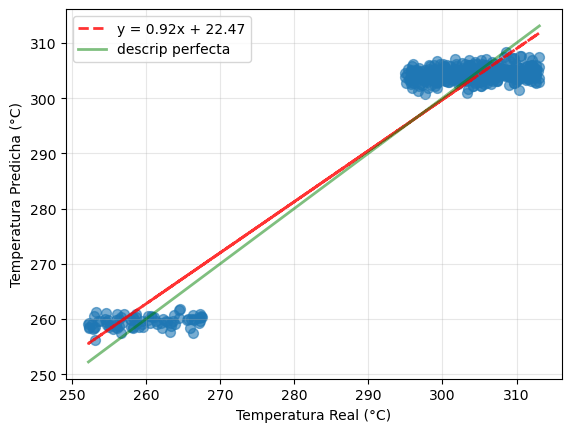

In [16]:
# graficar
y_pred = y_pred_train
y_real = y_train
    
# linea de regresión para las predicciones
z = np.polyfit(y_real, y_pred, 1)
p = np.poly1d(z)
    
plt.scatter(y_real, y_pred, alpha=0.6, s=50)
plt.plot(y_real, p(y_real), "r--", alpha=0.8, linewidth=2, 
             label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
    
plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 
             'g-', alpha=0.5, linewidth=2, label='descrip perfecta')
    
plt.xlabel('Temperatura Real (°C)')
plt.ylabel('Temperatura Predicha (°C)')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Ejercicios: mejorar la regresion lineal

- Para la simulacion, intente distintas variaciones de sus datos simulados, dé una variacion informada (educada)
- Para la regresion lineal, pruebe varias combinaciones de variables objetivos
- Haga una regresion linea con las mismas variables, pero solo usando datos originales (sin simulacion)
- Compare sus resultados de los dos puntos anteriores
- Esta es el primer contacto de como simular datos apartir de una base de datos chica, vaya pensando como puede mejorar esta simulacion


Con base de datos original

MSE Train: 0.00, MSE Test: 0.00
R2 Train: 1.00, R2 Test: nan


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


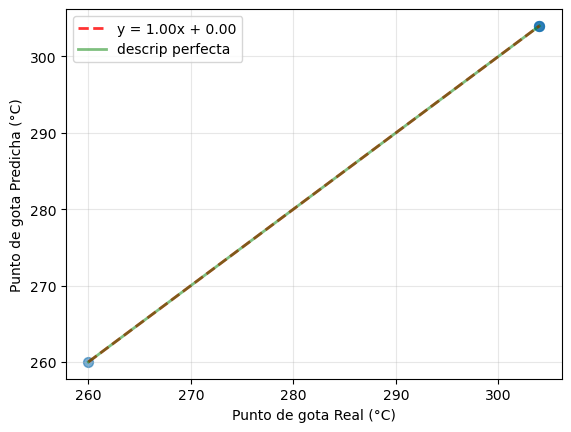

In [17]:
expanded_data = pd.read_csv('transformed_data_interlub.csv')

# definir variable objetivo
variable_objetivo = 'Punto de Gota, °C'

# definir variables predictoras
variables_predictoras = list(expanded_data.drop(columns=[variable_objetivo]).columns)


X, y = variables_regresion(expanded_data, variable_objetivo, variables_predictoras)

test_size = 0.2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    
#agregar comentarios

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
    
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)
    
y_pred_train = modelo.predict(X_train_scaled)
y_pred_test = modelo.predict(X_test_scaled)
    
# metricas
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print(f'MSE Train: {mse_train:.2f}, MSE Test: {mse_test:.2f}')

# agregar R cuadrada
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
print(f'R2 Train: {r2_train:.2f}, R2 Test: {r2_test:.2f}')

# graficar
y_pred = y_pred_train
y_real = y_train
    
# linea de regresión para las predicciones
z = np.polyfit(y_real, y_pred, 1)
p = np.poly1d(z)
    
plt.scatter(y_real, y_pred, alpha=0.6, s=50)
plt.plot(y_real, p(y_real), "r--", alpha=0.8, linewidth=2, 
             label=f'y = {z[0]:.2f}x + {z[1]:.2f}')
    
plt.plot([y_real.min(), y_real.max()], [y_real.min(), y_real.max()], 
             'g-', alpha=0.5, linewidth=2, label='descrip perfecta')
    
plt.xlabel('Punto de gota Real (°C)')
plt.ylabel('Punto de gota Predicha (°C)')
plt.legend()
plt.grid(True, alpha=0.3)